# Inditex · Análisis de ratios (2020-2025)

**Autor:** Martín Peinado Miraflores · **Datos:** cuentas anuales consolidadas de Inditex (inditex.com), extraídas y validadas en `src/`.

Este cuaderno responde a cuatro preguntas antes de valorar la empresa:

1. ¿Cuánto crece y cómo de rentable es?
2. ¿Cómo de bien usa el capital? (ROE, ROIC, DuPont)
3. ¿Cómo gestiona el circulante y qué solidez financiera tiene?
4. ¿Convierte beneficio en caja y cuánto devuelve al accionista?

**Convenciones:** importes en millones de euros salvo indicación. El ejercicio *N* termina el 31 de enero de *N+1* (el "2025" de Inditex es feb 2025 - ene 2026). Los ratios usan saldos de fin de ejercicio.


In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GRAF = ROOT / "informe" / "graficos"
GRAF.mkdir(parents=True, exist_ok=True)

w = pd.read_csv(ROOT / "data" / "processed" / "inditex_financials.csv", index_col="ejercicio")
w.index = w.index.astype(int)
w.tail(2).T.head(8)

ejercicio,2024,2025
ventas,38632.0,39864.0
coste_mercancia,-16288.0,-16642.0
margen_bruto,22343.0,23222.0
gastos_explotacion,-11555.0,-11878.0
otras_pyg,-60.0,-77.0
ebitda,10728.0,11267.0
otros_resultados,0.0,0.0
amortizaciones,-3174.0,-3270.0


## 1. Cálculo de ratios

Definiciones que conviene tener claras:

- **Tipo efectivo** = impuesto sobre beneficios / BAI.
- **NOPAT** = EBIT × (1 − tipo efectivo).
- **Capital invertido operativo** = patrimonio neto + deuda financiera + pasivos por arrendamiento − caja − inversiones financieras temporales. Incluye los arrendamientos porque, con la NIIF 16, son financiación de las tiendas.
- **ROIC** = NOPAT / capital invertido operativo.
- **FCF** = flujo de explotación − capex (material + intangible). **FCF tras arrendamientos** = FCF − pagos por arrendamiento (la NIIF 16 los sitúa en financiación, pero son un coste real de operar las tiendas).
- **Ciclo de caja** = días de inventario + días de cobro − días de pago. Los *acreedores* del balance incluyen más que proveedores comerciales (personal, otros), así que los días de pago están algo sobrestimados.


In [2]:
r = pd.DataFrame(index=w.index)

# Crecimiento y rentabilidad
r["ventas_mm"] = w.ventas / 1000
r["crec_ventas"] = w.ventas.pct_change() * 100
r["margen_bruto"] = w.margen_bruto / w.ventas * 100
r["margen_ebitda"] = w.ebitda / w.ventas * 100
r["margen_ebit"] = w.ebit / w.ventas * 100
r["margen_ebit_aj"] = (w.ebit - w.otros_resultados) / w.ventas * 100   # sin la partida excepcional de 2022
r["margen_neto"] = w.resultado_neto / w.ventas * 100

# Retorno sobre el capital
tipo = -w.impuesto_beneficios / w.bai
deuda = w.deuda_financiera_lp + w.deuda_financiera_cp
arrend = w.arrendamiento_lp + w.arrendamiento_cp
caja = w.efectivo + w.inv_financieras_temporales
cap_inv = w.patrimonio_neto + deuda + arrend - caja
r["tipo_efectivo"] = tipo * 100
r["roe"] = w.resultado_neto / w.patrimonio_neto * 100
r["roa"] = w.resultado_neto / w.total_activo * 100
r["roic"] = w.ebit * (1 - tipo) / cap_inv * 100
r["rotacion_activos"] = w.ventas / w.total_activo
r["apalancamiento"] = w.total_activo / w.patrimonio_neto

# Circulante
r["dias_inventario"] = w.existencias / -w.coste_mercancia * 365
r["dias_cobro"] = w.deudores / w.ventas * 365
r["dias_pago"] = w.acreedores / -w.coste_mercancia * 365
r["ciclo_caja"] = r.dias_inventario + r.dias_cobro - r.dias_pago

# Liquidez y solvencia
r["liquidez_corriente"] = w.activo_corriente / w.pasivo_corriente
r["prueba_acida"] = (w.activo_corriente - w.existencias) / w.pasivo_corriente
r["ratio_caja"] = caja / w.pasivo_corriente
r["caja_total_mm"] = caja / 1000
r["arrendamientos_mm"] = arrend / 1000
r["caja_neta_mm"] = (caja - deuda) / 1000
r["caja_neta_tras_arrend_mm"] = (caja - deuda - arrend) / 1000

# Caja y retribución
capex = -(w.capex_material + w.capex_intangible)
fcf = w.flujo_explotacion - capex
fcf_post = fcf + w.pago_arrendamientos
div = -w.dividendos
r["cfo_mm"] = w.flujo_explotacion / 1000
r["capex_mm"] = capex / 1000
r["capex_ventas"] = capex / w.ventas * 100
r["fcf_mm"] = fcf / 1000
r["fcf_tras_arrend_mm"] = fcf_post / 1000
r["dividendos_mm"] = div / 1000
r["payout"] = div / w.resultado_neto * 100
r["conversion_caja"] = fcf_post / w.resultado_neto * 100

r.to_csv(ROOT / "data" / "processed" / "inditex_ratios.csv", encoding="utf-8")
r.round(1).T

ejercicio,2020,2021,2022,2023,2024,2025
ventas_mm,20.4,27.7,32.6,35.9,38.6,39.9
crec_ventas,NaN,35.8,17.5,10.4,7.5,3.2
margen_bruto,55.8,57.1,57.0,57.8,57.8,58.3
margen_ebitda,22.3,25.9,26.6,27.4,27.8,28.3
margen_ebit,7.4,15.4,16.9,18.9,19.6,20.1
margen_ebit_aj,7.4,15.4,17.7,18.9,19.6,20.1
margen_neto,5.4,11.7,12.7,15.0,15.2,15.6
tipo_efectivo,21.2,22.6,22.6,21.5,22.4,22.4
roe,7.6,20.6,24.3,28.9,29.9,30.5
roa,4.2,11.2,13.8,16.5,16.9,17.5


### Comprobación rápida de coherencia

DuPont: ROE = margen neto × rotación de activos × apalancamiento. Si no cuadra, algún ratio está mal calculado.

In [3]:
dupont = (r.margen_neto / 100) * r.rotacion_activos * r.apalancamiento * 100
chk = pd.DataFrame({"ROE": r.roe, "DuPont": dupont, "diferencia": r.roe - dupont}).round(2)
assert (chk["diferencia"].abs() < 0.01).all()
chk

,ROE,DuPont,diferencia
ejercicio,,,
2020,7.59,7.59,0.0
2021,20.62,20.62,0.0
2022,24.35,24.35,0.0
2023,28.89,28.89,0.0
2024,29.87,29.87,-0.0
2025,30.50,30.50,-0.0


## 2. Estilo de los gráficos

Paleta de tres colores validada (separación para daltonismo y contraste). Una sola escala por gráfico, etiquetas directas en los extremos y texto siempre en tinta neutra.

In [4]:
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "font.family": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
})


def es(x, d=1):
    # Formato español: 1.234,5
    return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def lienzo(titulo, subtitulo, fuente="Fuente: cuentas anuales consolidadas de Inditex. Elaboración propia."):
    fig, ax = plt.subplots(figsize=(10, 5.6))
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    fig.text(0.06, 0.95, titulo, fontsize=17, fontweight="bold", color=INK, ha="left", va="top")
    fig.text(0.06, 0.885, subtitulo, fontsize=11.5, color=INK2, ha="left", va="top")
    fig.text(0.06, 0.025, fuente, fontsize=8.5, color=MUTED, ha="left", va="bottom")
    fig.subplots_adjust(left=0.07, right=0.84, top=0.78, bottom=0.17)
    return fig, ax


def guardar(fig, nombre):
    fig.savefig(GRAF / nombre, facecolor=SURFACE)
    plt.show()


def lineas(ax, series, colores, fmt):
    # Lineas de 2 px con marcador final de 8 px y anillo del color de la superficie; etiqueta directa al final.
    x = list(series[0][1].index)
    for (nombre, s), c in zip(series, colores):
        ax.plot(x, s.values, color=c, linewidth=2, solid_capstyle="round", solid_joinstyle="round", zorder=3)
        ax.plot(x[-1], s.values[-1], "o", color=c, markersize=9, markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
        ax.annotate(f"{nombre}  {fmt(s.values[-1])}", (x[-1], s.values[-1]), xytext=(12, 0),
                    textcoords="offset points", va="center", fontsize=10.5, color=INK2, annotation_clip=False,
                    bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
    ax.set_xticks(x)
    ax.set_xlim(x[0] - 0.2, x[-1] + 0.2)
    ax.legend(handles=[plt.Line2D([0], [0], color=c, lw=2) for c in colores], labels=[n for n, _ in series],
              loc="upper left", frameon=False, ncol=len(series), fontsize=10,
              labelcolor=INK2, bbox_to_anchor=(0, 1.08))

## 3. Crecimiento: las ventas siguen subiendo, pero cada vez más despacio

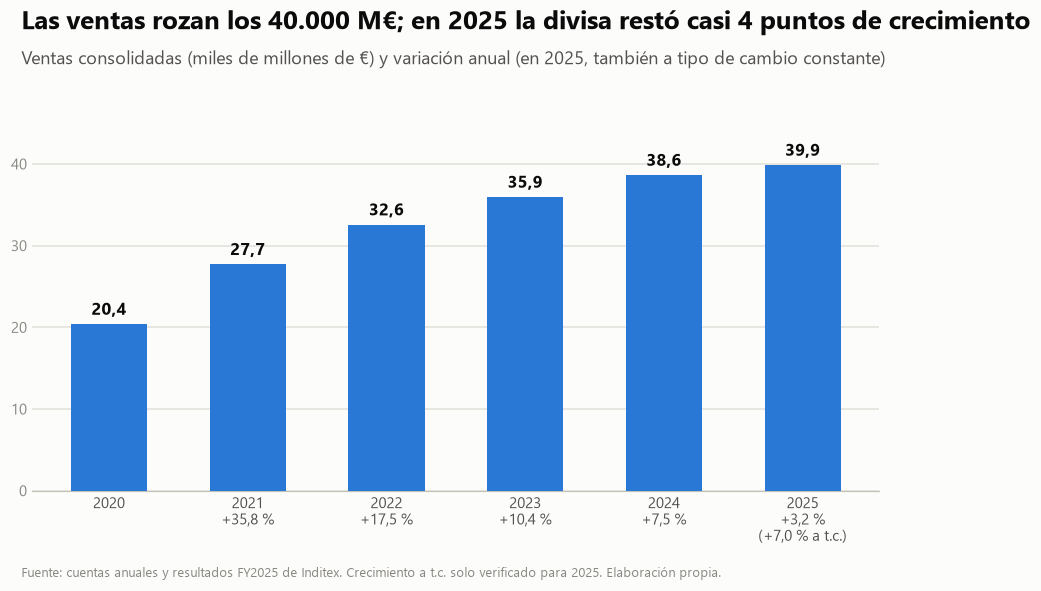

In [5]:
# Crecimiento a tipo de cambio constante (t.c.) publicado por Inditex; solo lo tengo verificado para 2025.
TC = {2025: 7.0}
fig, ax = lienzo("Las ventas rozan los 40.000 M€; en 2025 la divisa restó casi 4 puntos de crecimiento",
                 "Ventas consolidadas (miles de millones de €) y variación anual (en 2025, también a tipo de cambio constante)",
                 "Fuente: cuentas anuales y resultados FY2025 de Inditex. Crecimiento a t.c. solo verificado para 2025. Elaboración propia.")
x = r.index.values
ax.bar(x, r.ventas_mm, width=0.55, color=BLUE, zorder=3)
for xi, v in zip(x, r.ventas_mm):
    ax.text(xi, v + 0.7, es(v), ha="center", va="bottom", fontsize=11, color=INK, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n{'' if np.isnan(c) else ('+' if c >= 0 else '') + es(c) + ' %'}"
                    + (f"\n(+{es(TC[a])} % a t.c.)" if a in TC else "")
                    for a, c in zip(x, r.crec_ventas)], color=INK2)
ax.set_ylim(0, 46)
ax.set_yticks([0, 10, 20, 30, 40])
guardar(fig, "01_ventas.png")

## 4. Rentabilidad: márgenes en máximos

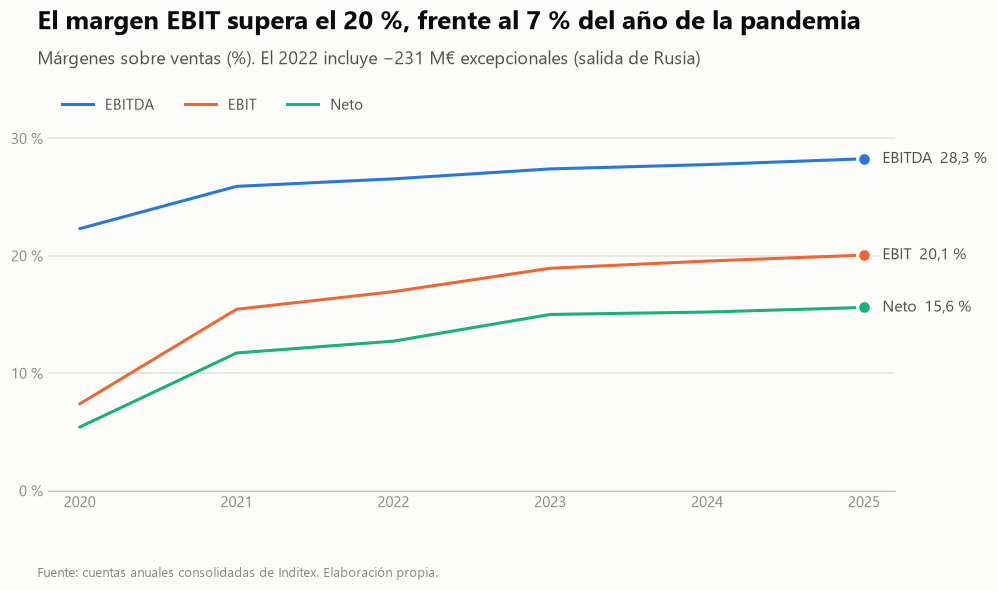

In [6]:
fig, ax = lienzo("El margen EBIT supera el 20 %, frente al 7 % del año de la pandemia",
                 "Márgenes sobre ventas (%). El 2022 incluye −231 M€ excepcionales (salida de Rusia)")
lineas(ax, [("EBITDA", r.margen_ebitda), ("EBIT", r.margen_ebit), ("Neto", r.margen_neto)],
       [BLUE, ORANGE, AQUA], lambda v: es(v) + " %")
ax.set_ylim(0, 32)
ax.set_yticks([0, 10, 20, 30])
ax.set_yticklabels([f"{t} %" for t in (0, 10, 20, 30)])
guardar(fig, "02_margenes.png")

## 5. Retorno sobre el capital: ROE y ROIC

El ROE (30 %) está inflado por el apalancamiento contable (activo/patrimonio ≈ 1,7) y por los arrendamientos. El ROIC, que trata los arrendamientos como financiación y descuenta la caja, mide mejor el negocio.

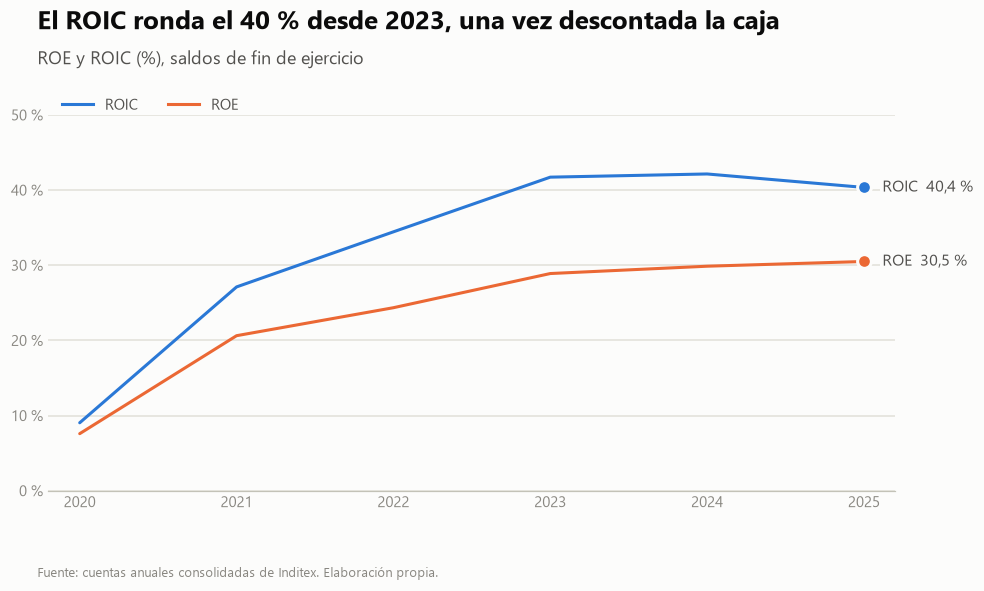

ejercicio,2020,2021,2022,2023,2024,2025
Margen neto %,5.41,11.73,12.73,15.01,15.21,15.60
Rotación activos (x),0.77,0.96,1.09,1.10,1.11,1.12
Apalancamiento (x),1.82,1.84,1.76,1.75,1.76,1.75
ROE %,7.59,20.62,24.35,28.89,29.87,30.50


In [7]:
fig, ax = lienzo("El ROIC ronda el 40 % desde 2023, una vez descontada la caja",
                 "ROE y ROIC (%), saldos de fin de ejercicio")
lineas(ax, [("ROIC", r.roic), ("ROE", r.roe)], [BLUE, ORANGE], lambda v: es(v) + " %")
ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.set_yticklabels([f"{t} %" for t in (0, 10, 20, 30, 40, 50)])
guardar(fig, "03_roe_roic.png")

dup = pd.DataFrame({"Margen neto %": r.margen_neto, "Rotación activos (x)": r.rotacion_activos,
                    "Apalancamiento (x)": r.apalancamiento, "ROE %": r.roe}).round(2).T
dup

## 6. Circulante: Inditex cobra antes de pagar

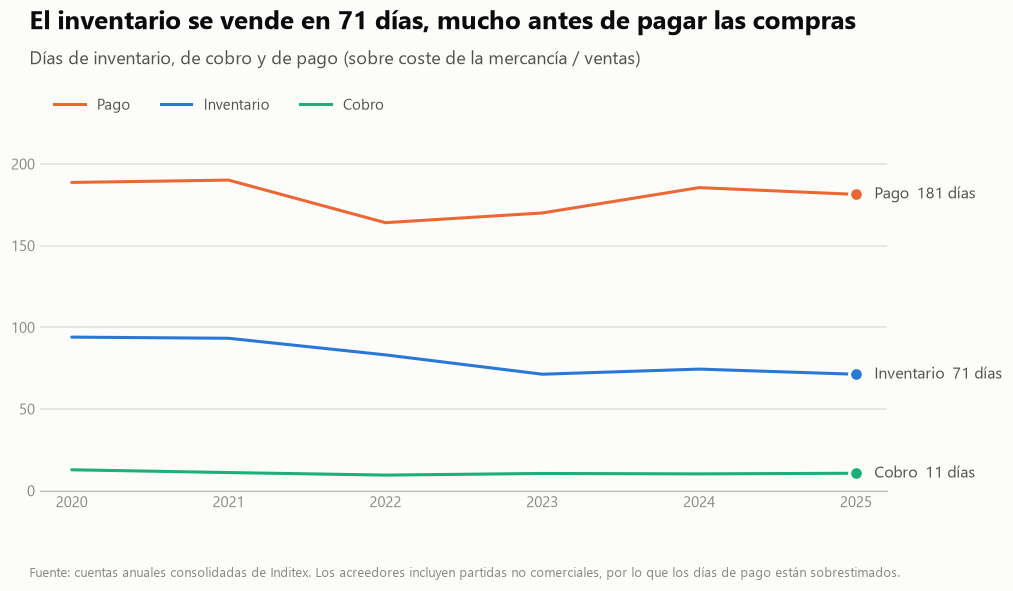

ejercicio,2020,2021,2022,2023,2024,2025
dias_inventario,94.0,93.0,83.0,71.0,74.0,71.0
dias_cobro,13.0,11.0,10.0,11.0,10.0,11.0
dias_pago,189.0,190.0,164.0,170.0,186.0,181.0
ciclo_caja,-82.0,-86.0,-71.0,-88.0,-101.0,-99.0


In [8]:
fig, ax = lienzo("El inventario se vende en 71 días, mucho antes de pagar las compras",
                 "Días de inventario, de cobro y de pago (sobre coste de la mercancía / ventas)",
                 "Fuente: cuentas anuales consolidadas de Inditex. Los acreedores incluyen partidas no comerciales, por lo que los días de pago están sobrestimados.")
lineas(ax, [("Pago", r.dias_pago), ("Inventario", r.dias_inventario), ("Cobro", r.dias_cobro)],
       [ORANGE, BLUE, AQUA], lambda v: es(v, 0) + " días")
ax.set_ylim(0, 230)
ax.set_yticks([0, 50, 100, 150, 200])
guardar(fig, "04_circulante.png")
r[["dias_inventario", "dias_cobro", "dias_pago", "ciclo_caja"]].round(0).T

## 7. Solidez financiera y caja

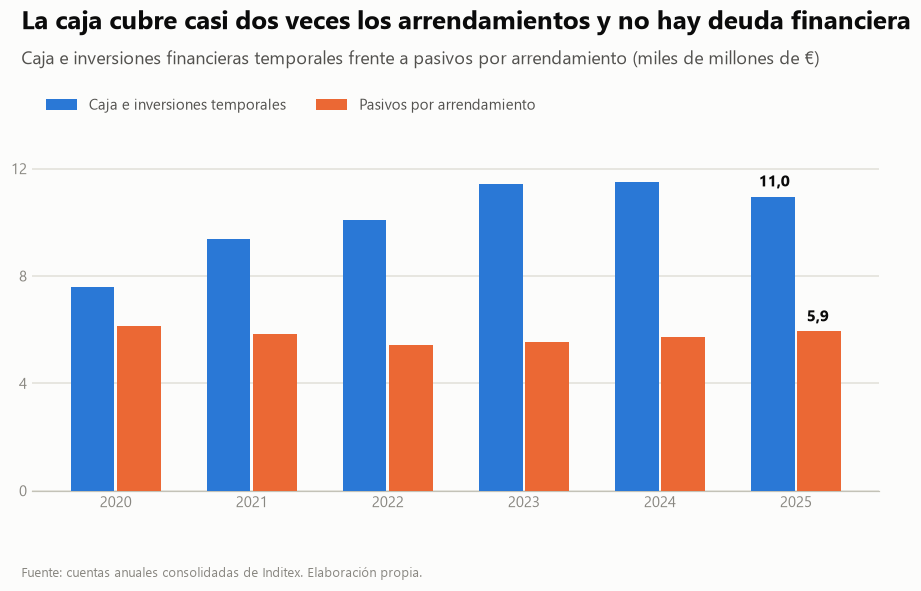

In [9]:
fig, ax = lienzo("La caja cubre casi dos veces los arrendamientos y no hay deuda financiera",
                 "Caja e inversiones financieras temporales frente a pasivos por arrendamiento (miles de millones de €)")
x = r.index.values
ancho = 0.32
ax.bar(x - ancho / 2 - 0.01, r.caja_total_mm, width=ancho, color=BLUE, zorder=3, label="Caja e inversiones temporales")
ax.bar(x + ancho / 2 + 0.01, r.arrendamientos_mm, width=ancho, color=ORANGE, zorder=3, label="Pasivos por arrendamiento")
for serie, dx in ((r.caja_total_mm, -ancho / 2), (r.arrendamientos_mm, ancho / 2)):
    ax.text(x[-1] + dx, serie.iloc[-1] + 0.25, es(serie.iloc[-1]), ha="center", va="bottom", fontsize=10.5,
            color=INK, fontweight="bold")
ax.set_xticks(x)
ax.set_ylim(0, 14)
ax.set_yticks([0, 4, 8, 12])
ax.legend(loc="upper left", frameon=False, ncol=2, fontsize=10, labelcolor=INK2, bbox_to_anchor=(0, 1.08))
guardar(fig, "05_caja_arrendamientos.png")

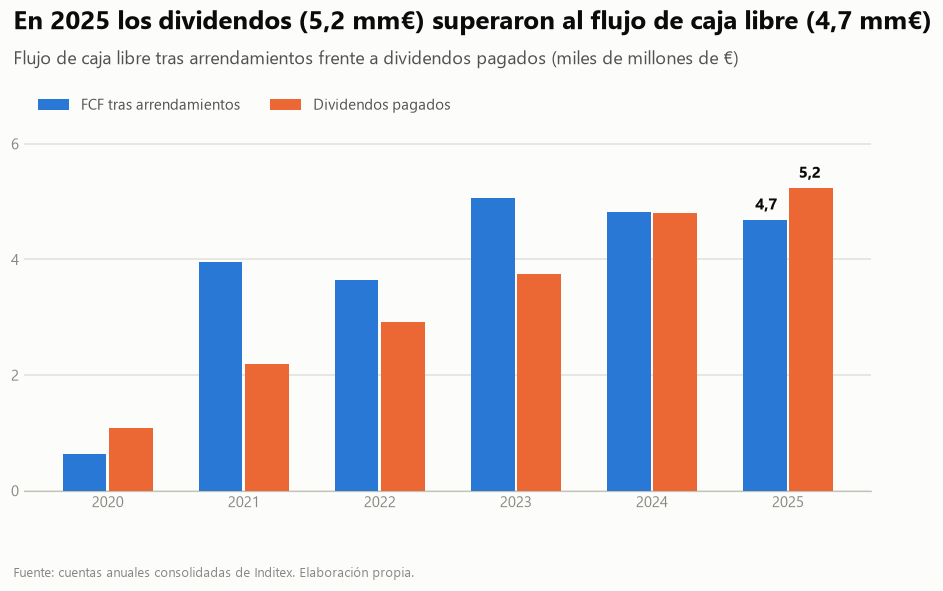

ejercicio,2020,2021,2022,2023,2024,2025
cfo_mm,3.0,6.8,6.7,8.7,9.3,9.2
capex_mm,0.7,1.1,1.4,1.9,2.7,2.7
fcf_mm,2.3,5.6,5.3,6.8,6.6,6.5
fcf_tras_arrend_mm,0.6,4.0,3.6,5.1,4.8,4.7
dividendos_mm,1.1,2.2,2.9,3.7,4.8,5.2
payout,98.7,67.4,70.3,69.4,81.6,84.2
conversion_caja,57.6,121.8,87.7,93.8,81.9,75.3
capex_ventas,3.5,4.1,4.3,5.2,6.9,6.8


In [10]:
fig, ax = lienzo("En 2025 los dividendos (5,2 mm€) superaron al flujo de caja libre (4,7 mm€)",
                 "Flujo de caja libre tras arrendamientos frente a dividendos pagados (miles de millones de €)")
ax.bar(x - ancho / 2 - 0.01, r.fcf_tras_arrend_mm, width=ancho, color=BLUE, zorder=3, label="FCF tras arrendamientos")
ax.bar(x + ancho / 2 + 0.01, r.dividendos_mm, width=ancho, color=ORANGE, zorder=3, label="Dividendos pagados")
for serie, dx in ((r.fcf_tras_arrend_mm, -ancho / 2), (r.dividendos_mm, ancho / 2)):
    ax.text(x[-1] + dx, serie.iloc[-1] + 0.12, es(serie.iloc[-1]), ha="center", va="bottom", fontsize=10.5,
            color=INK, fontweight="bold")
ax.set_xticks(x)
ax.set_ylim(0, 6.5)
ax.set_yticks([0, 2, 4, 6])
ax.legend(loc="upper left", frameon=False, ncol=2, fontsize=10, labelcolor=INK2, bbox_to_anchor=(0, 1.08))
guardar(fig, "06_fcf_dividendos.png")

r[["cfo_mm", "capex_mm", "fcf_mm", "fcf_tras_arrend_mm", "dividendos_mm", "payout", "conversion_caja", "capex_ventas"]].round(1).T

## 8. Conclusiones

**Lo que dicen los datos (ejercicio 2025 salvo indicación):**

1. **Un negocio muy rentable.** Margen bruto 58,3 %, EBITDA 28,3 %, EBIT 20,1 %, neto 15,6 %. ROIC 40,4 % y ROE 30,5 %. El 2020 (EBIT 7,4 %) está distorsionado por la pandemia, así que la comparación útil es 2021 (15,4 %) frente a 2025 (20,1 %).
2. **El crecimiento sigue sano; el +3,2 % reportado de 2025 lo distorsiona la divisa.** Serie reportada: +35,8 % (2021, rebote tras la pandemia), +17,5 %, +10,4 %, +7,5 % y +3,2 %. Pero a **tipo de cambio constante** las ventas de 2025 crecieron un **+7,0 %** (resultados FY2025 de Inditex), en el primer semestre de 2026 un +9,2 % (+7,6 % reportado) y entre el 1 de agosto y el 7 de septiembre de 2026 un +9 %. Para los años anteriores a 2025 no he separado el efecto divisa. *(Corrección: una primera versión de este cuaderno hablaba de un frenazo del crecimiento; era una lectura incompleta.)*
3. **La inversión se ha duplicado y la caja operativa no.** El capex pasa de 1.415 M€ (4,3 % de ventas) en 2022 a 2.712 M€ (6,8 %) en 2025, mientras el flujo de explotación se queda en ≈9.200 M€. Para 2026 Inditex guía ≈2.300 M€ de inversión ordinaria más ≈200 M€ extraordinarios. El FCF tras arrendamientos tocó techo en 2023 (5.100 M€) y baja a 4.700 M€ en 2025.
4. **Los dividendos superan al FCF, pero es una decisión de reparto, no tensión.** La política de Inditex es un payout ordinario del 60 % más dividendos extraordinarios: el dividendo de 2025 es de 1,75 € por acción (1,20 € ordinario + 0,55 € extraordinario), pagado en dos veces de 0,875 € (4 de mayo y 2 de noviembre de 2026). En 2025 se pagaron 5.235 M€ frente a un FCF tras arrendamientos de 4.686 M€; la caja baja de 11.500 a 10.960 M€, pero sigue siendo un colchón enorme. El componente extraordinario explica probablemente buena parte de la diferencia, aunque no he desglosado el pago.
5. **Balance muy sólido.** Caja e inversiones temporales de 10.960 M€, deuda financiera casi nula (2 M€), arrendamientos de 5.933 M€: caja neta de ≈5.000 M€ incluso tras restarlos. Liquidez corriente de 1,5.
6. **El circulante financia el crecimiento.** Ciclo de caja de ≈ −99 días: se vende el inventario (71 días) mucho antes de pagar a los acreedores. Mientras Inditex crezca, esto libera caja.

**Qué implica para el DCF (semana 2):**

- La hipótesis clave es la **senda de crecimiento**. Datos de partida: +7,6 % reportado en el 1S2026, guía de espacio bruto ≈ +5 % en 2026 e impacto divisa ≈ −1 % en ventas. Hay que decidir cuánto dura ese ritmo y a qué valor de largo plazo converge.
- ¿Vuelve el **capex** a un 4-5 % de ventas o se queda en ≈6-7 %? Cambia mucho el valor.
- **Arrendamientos (NIIF 16):** el EBITDA no incluye el alquiler de las tiendas. Hay que tratarlos de forma coherente (como coste operativo o como deuda), sin ignorarlos ni contarlos dos veces.
- **Normalizar** la partida excepcional de −231 M€ de 2022 y usar un tipo impositivo ≈22,5 % (el efectivo de los últimos cinco años y del primer semestre de 2026).

**Límites de este análisis:** ratios con saldos de fin de ejercicio (no medias), solo cinco ejercicios de los cuales uno afectado por la pandemia, crecimiento a tipo constante verificado solo para 2025, y todavía sin comparación con competidores (H&M, Primark/ABF, Fast Retailing), que llegará con los múltiplos.


In [11]:
# Resumen final para consulta rápida
resumen = r[["ventas_mm", "crec_ventas", "margen_ebit", "margen_neto", "roic", "roe", "ciclo_caja",
             "caja_neta_mm", "fcf_tras_arrend_mm", "payout"]].round(1)
resumen.columns = ["Ventas (mm€)", "Crec. %", "Margen EBIT %", "Margen neto %", "ROIC %", "ROE %",
                   "Ciclo caja (días)", "Caja neta (mm€)", "FCF tras arrend. (mm€)", "Payout %"]
resumen.T

ejercicio,2020,2021,2022,2023,2024,2025
Ventas (mm€),20.4,27.7,32.6,35.9,38.6,39.9
Crec. %,NaN,35.8,17.5,10.4,7.5,3.2
Margen EBIT %,7.4,15.4,16.9,18.9,19.6,20.1
Margen neto %,5.4,11.7,12.7,15.0,15.2,15.6
ROIC %,9.0,27.1,34.4,41.7,42.1,40.4
ROE %,7.6,20.6,24.3,28.9,29.9,30.5
Ciclo caja (días),-81.9,-85.7,-71.4,-88.1,-100.8,-99.4
Caja neta (mm€),7.6,9.4,10.1,11.4,11.5,11.0
FCF tras arrend. (mm€),0.6,4.0,3.6,5.1,4.8,4.7
Payout %,98.7,67.4,70.3,69.4,81.6,84.2
